In [213]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, center_in_box
import os
import numpy as np
import freud
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.optimize import curve_fit

In [214]:
lipids = 4000
N = 32

In [215]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"
top_file = os.path.join(dir, "tests/bilayer.data")
traj_file = os.path.join(dir, "tests/bilayer_ps.lammpstrj")

In [216]:
traj_acf_file = os.path.join(dir, "tests/bilayer_acf.lammpstrj")

In [217]:
u = mda.Universe(top_file, format="DATA", atom_style = "id resid type charge x y z")
u.load_new(traj_file, format="LAMMPSDUMP", dt=0.01)

<Universe with 176081 atoms>

In [218]:
frames = len(u.trajectory)
timestep = u.trajectory.dt
timescale = 0.0912 # ns
steps = 300000
steps_per_frame = steps/frames
time_per_frame = steps_per_frame*timestep*timescale
print(f"time per frame {time_per_frame}")

time per frame 2.736


In [219]:
u_acf = mda.Universe(top_file, format="DATA", atom_style = "id resid type charge x y z")
u_acf.load_new(traj_acf_file, format="LAMMPSDUMP", dt=0.01)

<Universe with 176081 atoms>

In [220]:
frames_acf = len(u_acf.trajectory)
timestep_acf = u_acf.trajectory.dt
timescale = 0.0912 # ns
steps_acf = 10000
steps_per_frame_acf = steps_acf/frames_acf
time_per_frame_acf = steps_per_frame_acf*timestep_acf*timescale
print(f"acf timer per frame {time_per_frame_acf}")

acf timer per frame 0.09029702970297031


In [221]:
lipid_atoms = u.select_atoms(f"resid 1:{lipids}")

transforms = unwrap(lipid_atoms)
u.trajectory.add_transformations(transforms)

In [222]:
lipid_atoms_acf = u_acf.select_atoms(f"resid 1:{lipids}")

transforms_acf = unwrap(lipid_atoms_acf)
u_acf.trajectory.add_transformations(transforms_acf)

In [223]:
nematic = freud.order.Nematic()

In [224]:
def neamtic_order(universe):

    s_values = np.zeros(len(universe.trajectory))
    directors = np.zeros((len(universe.trajectory), 3))

    lipid_res = universe.residues[:lipids]

    for frame_id, frame in enumerate(universe.trajectory):


        orientations = np.zeros((len(lipid_res), 3))

        for mol_id, mol in enumerate(lipid_res):

            positions = mol.atoms.positions
            orientation_long = (positions[7] + positions[11])/2 - positions[0]
            orientations[mol_id] = orientation_long/np.linalg.norm(orientation_long)

        nematic.compute(orientations)

        s_values[frame_id] = nematic.order
        directors[frame_id] = nematic.director

    return s_values, directors

In [225]:
s_values, directors = neamtic_order(u)

In [226]:
s_values_acf, directors_acf = neamtic_order(u_acf)

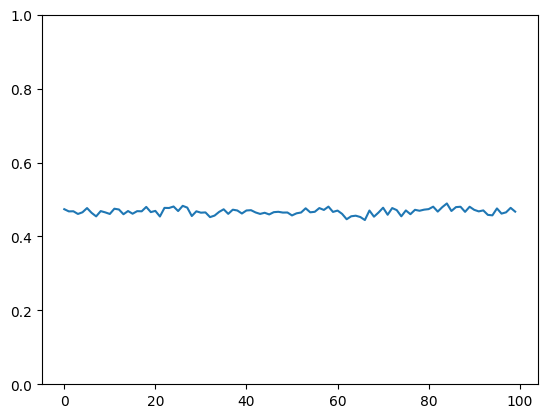

(0.0, 1.0)

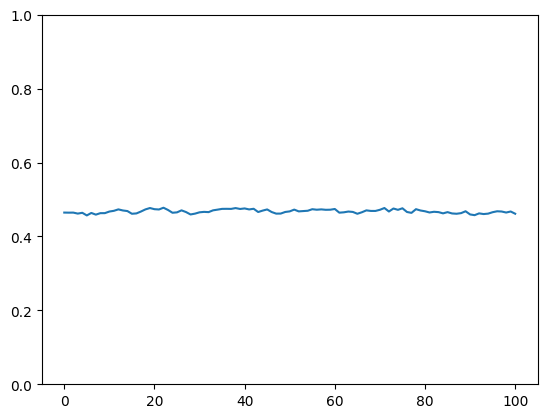

In [227]:
plt.plot(s_values)

plt.ylim((0,1))
plt.show()

plt.plot(s_values_acf)
plt.ylim((0,1))

In [228]:
def grids_per_frame(universe, directors, N = N):

    n_frames = len(universe.trajectory)
    lipid_res = universe.residues[:lipids]

    grids = np.zeros((n_frames, N, N))

    for frame_id, frame in enumerate(universe.trajectory):

        box_x, box_y = universe.dimensions[0], universe.dimensions[1]

        coms = []
        for mol in lipid_res:
            positions = mol.atoms.positions
            #tail_middle = (positions[7] + positions[11])/2
            coms.append(positions[0])

        x = [t[0] for t in coms]
        y = [t[1] for t in coms]

        director = directors[frame_id]
        z = [(t @ director) for t in coms]
        z = z - np.mean(z)

        

        h_grid, x_edges, y_edges, bin_numbers = binned_statistic_2d(x, y, z, statistic="mean", bins=[N,N], range=[[0,box_x], [0,box_y]])

        h_grid = np.nan_to_num(h_grid, nan=0.0)

        grids[frame_id] = h_grid

    return grids

In [229]:
grids_acf = grids_per_frame(u_acf, directors_acf)

In [230]:
def autocorr_gridpoints(grids):

    n_frames, N, N = grids.shape

    acf_all = []

    for i in range(N):
        for j in range(N):
            time_series = grids[:,i,j]

            if np.std(time_series) > 1e-10:

                data = time_series - np.mean(time_series)

                acf = np.correlate(data, data, mode="full")
                acf = acf[len(acf)//2:]
                acf = acf/acf[0]

                acf_all.append(acf)

    acf_mean = np.mean(acf_all, axis=0)

    return acf_mean


In [231]:
acf = autocorr_gridpoints(grids_acf)

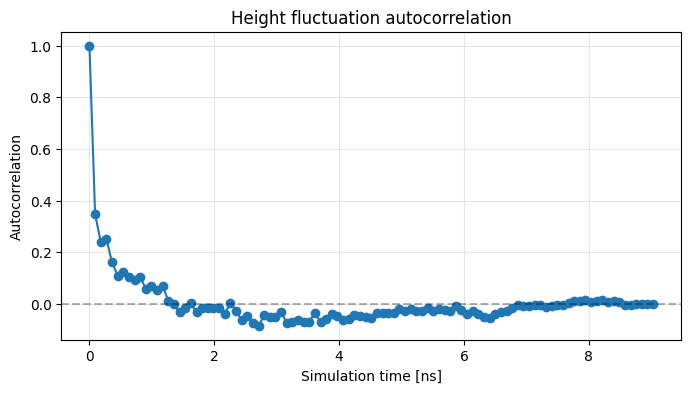

In [232]:
frame_axis_acf = np.arange(len(u_acf.trajectory))

plt.figure(figsize=(8,4))
plt.plot(frame_axis_acf*time_per_frame_acf,acf, 'o-')
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Simulation time [ns]')
plt.ylabel('Autocorrelation')
plt.grid(True, alpha=0.3)
plt.title('Height fluctuation autocorrelation')
plt.show()

In [233]:
print(f"Decorrelation after 2 ns, meaning {2/timescale} tau, which are {2/timescale*100} steps rounded to {3000} steps")

Decorrelation after 2 ns, meaning 21.929824561403507 tau, which are 2192.9824561403507 steps rounded to 3000 steps


In [234]:
grids = grids_per_frame(u, directors)

In [235]:
grids.shape

(100, 32, 32)

In [236]:
def power_spectrum(universe, grids, N = N):
    
    n_frames = len(universe.trajectory)

    h_qs = [np.fft.fft2(grid) for grid in grids]

    avg_power_spectrum = np.zeros((N,N))

    for frame_id in range(n_frames):

        power_spectrum = np.abs(h_qs[frame_id])**2
        avg_power_spectrum += power_spectrum

    avg_power_spectrum = avg_power_spectrum/n_frames

    box_x, box_y = universe.dimensions[0], universe.dimensions[1]
    avg_power_spectrum = np.fft.fftshift(avg_power_spectrum)* (box_x*box_y) / N**4

    print(f"Grid shape: {grids[0].shape}")
    print(f"Real space: <h²> = {np.mean(grids**2):.6f} σ²")
    
    parseval = np.sum(avg_power_spectrum) / (box_x * box_y)
    print(f"Parseval: {parseval:.6f} σ² (sollte ≈ {np.mean(grids**2):.6f} sein)")
    
    if abs(parseval - np.mean(grids**2)) / np.mean(grids**2) > 0.1:
        print("  WARNUNG: Parseval-Theorem nicht erfüllt!")

    return avg_power_spectrum

In [237]:
avg_power_spectrum = power_spectrum(u, grids)

print(avg_power_spectrum)

Grid shape: (32, 32)
Real space: <h²> = 0.842712 σ²
Parseval: 0.842712 σ² (sollte ≈ 0.842712 sein)
[[1.92569618 1.64607291 1.93442397 ... 2.03847312 1.93442397 1.64607291]
 [2.03397339 1.78880994 1.81813257 ... 2.02139825 1.68681538 2.02682673]
 [1.67149103 1.82965123 1.7252259  ... 1.99879945 1.56794841 1.91278225]
 ...
 [1.62690143 1.88717785 1.96048176 ... 1.97709296 1.90721103 1.68496347]
 [1.67149103 1.91278225 1.56794841 ... 1.73069906 1.7252259  1.82965123]
 [2.03397339 2.02682673 1.68681538 ... 1.6737441  1.81813257 1.78880994]]


In [238]:
def q_norm(universe, N = N):

    box_x, box_y = universe.dimensions[0], universe.dimensions[1]
    dx, dy = box_x/N, box_y/N

    qx, qy = np.fft.fftshift(np.fft.fftfreq(N, dx)), np.fft.fftshift(np.fft.fftfreq(N, dy))
    QX, QY = np.meshgrid(qx, qy)

    sinc_x = np.sinc(QX * dx)
    sinc_y = np.sinc(QY * dy)

    corr_factor = sinc_x**2 * sinc_y**2

    Q_norm = np.sqrt(QX**2 + QY**2)

    return Q_norm, corr_factor


In [239]:
qs, corr_factor = q_norm(u)
print(corr_factor)

[[0.16425575 0.18509105 0.20637274 ... 0.22784712 0.20637274 0.18509105]
 [0.18509105 0.20856924 0.23255045 ... 0.25674878 0.23255045 0.20856924]
 [0.20637274 0.23255045 0.259289   ... 0.28626965 0.259289   0.23255045]
 ...
 [0.22784712 0.25674878 0.28626965 ... 0.3160578  0.28626965 0.25674878]
 [0.20637274 0.23255045 0.259289   ... 0.28626965 0.259289   0.23255045]
 [0.18509105 0.20856924 0.23255045 ... 0.25674878 0.23255045 0.20856924]]


In [240]:
avg_power_spectrum = avg_power_spectrum/corr_factor

In [241]:
print(avg_power_spectrum)

[[11.72376745  8.89331446  9.37344707 ...  8.94667064  9.37344707
   8.89331446]
 [10.98904236  8.57657588  7.81822864 ...  7.8730589   7.25354603
   9.71776426]
 [ 8.09937887  7.86776051  6.65367943 ...  6.98222631  6.04710726
   8.2252357 ]
 ...
 [ 7.14032044  7.35028949  6.84837456 ...  6.25547918  6.66228869
   6.56269325]
 [ 8.09937887  8.2252357   6.04710726 ...  6.04569532  6.65367943
   7.86776051]
 [10.98904236  9.71776426  7.25354603 ...  6.51899541  7.81822864
   8.57657588]]


In [242]:
def radial_profile(data, q_norm_grid, n_bins):

    q_max = np.max(q_norm_grid)
    q_bins = np.linspace(0, q_max, n_bins)
    q_centers = (q_bins[:-1] + q_bins[1:]) / 2

    radial_mean = []

    for i in range(len(q_bins) - 1):

        mask = (q_norm_grid >= q_bins[i]) & (q_norm_grid < q_bins[i+1])

        values = data[mask]

        if len(values) > 0:
            radial_mean.append(np.mean(values))
        else:
            radial_mean.append(np.nan)

    return q_centers, np.array(radial_mean)

In [243]:
q_radial, power_radial = radial_profile(avg_power_spectrum, qs, 100)

In [249]:
# def log_fit(log_q2, log_A, slope):

#     return log_A -slope*log_q2

def log_fit(log_q2, log_A):

    return log_A -2*log_q2

fit_mask = (q_radial**2 > 1e-4) & (q_radial**2 < 4e-3) & (q_radial > 1e-10) & (power_radial > 1e-10)
q_fit = q_radial[fit_mask]
power_fit = power_radial[fit_mask]

print(q_fit**2)
print(power_fit)

popt, pcov = curve_fit(log_fit, np.log(q_fit**2), np.log(power_fit))

log_A_fit = popt[0]
#exp = popt[1]
A_fit = np.exp(popt[0])

print(f"kappa = {1/A_fit}")
#print(f"exponent: {exp}")

[0.00030463 0.00063558 0.00108688 0.00135765 0.00235051 0.00274163
 0.00361414]
[162.50316209  79.00483157  30.35812201  26.55636202  11.13717618
  11.59692123   6.01860015]
kappa = 22374.4565240617


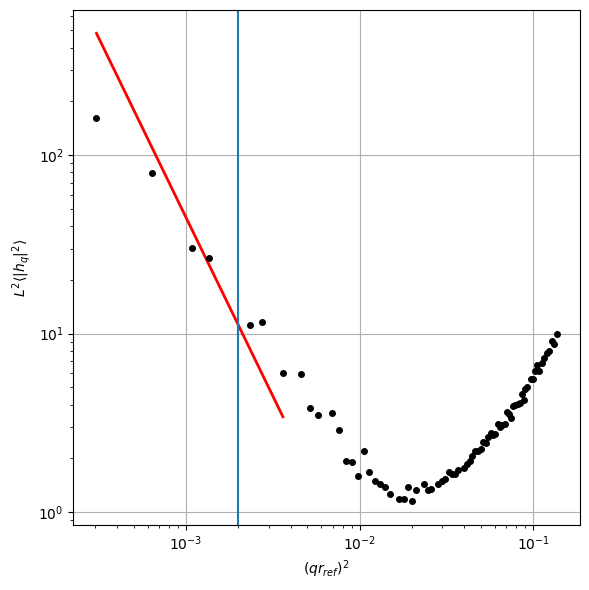

In [250]:
plt.figure(figsize=(6,6))


mask_nonzero = q_radial > 1e-10
q_plot = q_radial[mask_nonzero]
q_plot = q_radial[1:]
power_plot = power_radial[mask_nonzero]
power_plot = power_plot[1:]

q2_range = np.logspace(np.log10((q_fit**2).min()), np.log10((q_fit**2).max()), 100)
# plt.loglog(q2_range, np.exp(log_fit(np.log(q2_range), log_A_fit, exp)), 'r-', linewidth=2)
plt.loglog(q2_range, np.exp(log_fit(np.log(q2_range), log_A_fit)), 'r-', linewidth=2)

plt.loglog(q_plot**2, power_plot, 'o', color='black', markersize=4)
plt.axvline(2e-3)

plt.xlabel(r'$(qr_{ref})^2$')
plt.ylabel(r'$L^2 \langle |h_q|^2 \rangle$ ')
plt.grid()
plt.tight_layout()
plt.show()